# Phase 3: Model Training and Evaluation
## EfficientNetB2 for FER

**Steps:**
1. Load datasets
2. Train EfficientNetB2
3. Cross-dataset evaluation
4. Generate reports

In [1]:
# Install required packages (run once)
import sys
!{sys.executable} -m pip install typing_extensions --upgrade --quiet
!{sys.executable} -m pip install torch torchvision --quiet
!{sys.executable} -m pip install opencv-python scikit-learn scikit-image pillow --quiet
!{sys.executable} -m pip install efficientnet-pytorch --quiet
!{sys.executable} -m pip install facenet-pytorch --quiet
print("✓ All packages installed!")

✓ All packages installed!


In [2]:
import sys
sys.path.append('..')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from src.utils.config import Config, setup_seed, create_directories
from src.data.dataset_loader import FER2013Dataset, CKPlusDataset, JAFFEDataset, get_transforms
from src.models.efficientnet_model import EfficientNetFER
from src.models.trainer import FERTrainer
from src.evaluation.cross_dataset_eval import CrossDatasetEvaluator
from src.utils.visualization import plot_cross_dataset_performance

config = Config('../config/config.yaml')
setup_seed(config.get('project.random_seed'))
create_directories(config)

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')
%matplotlib inline

Device: mps


## 1. Load Datasets

In [3]:
train_transform = get_transforms(config, is_training=True)
test_transform = get_transforms(config, is_training=False)

# Fix paths - config paths are relative to project root, we're in notebooks/
# FER2013 only has train/test, use test as validation during training
fer_train = FER2013Dataset('../' + config.get('data.fer2013.path'), split='train', transform=train_transform)
fer_test = FER2013Dataset('../' + config.get('data.fer2013.path'), split='test', transform=test_transform)
fer_val = fer_test  # Use test set for validation during training
print(f'FER2013: Train={len(fer_train)}, Val={len(fer_val)}, Test={len(fer_test)}')

try:
    ckplus = CKPlusDataset('../' + config.get('data.ckplus.path'), transform=test_transform)
    print(f'CK+: {len(ckplus)}')
except Exception as e:
    print(f'CK+ not available: {e}')
    ckplus = None

try:
    jaffe = JAFFEDataset('../' + config.get('data.jaffe.path'), transform=test_transform)
    print(f'JAFFE: {len(jaffe)}')
except Exception as e:
    print(f'JAFFE not available: {e}')
    jaffe = None

Loading from: ../data/raw/FER2013/train


Loaded 28709 images from ../data/raw/FER2013/train
Loading from: ../data/raw/FER2013/test


Loaded 7178 images from ../data/raw/FER2013/test
FER2013: Train=28709, Val=7178, Test=7178
Loading from: ../data/raw/CK+48/ck+


Loaded 981 images from CK+
CK+: 981
Loading from: ../data/raw/jaffe/jaffe


Loading JAFFE: 100%|██████████| 213/213 [00:00<00:00, 2282.05it/s]

Loaded 213 images from JAFFE
JAFFE: 213


## 2. Create DataLoaders

In [4]:
batch_size = config.get('model.batch_size')

train_loader = DataLoader(fer_train, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(fer_val, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(fer_test, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

print(f'Batch size: {batch_size}')
print(f'Train batches: {len(train_loader)}')

Batch size: 16
Train batches: 1795


## 3. Create Model

In [5]:
model = EfficientNetFER(
    model_name=config.get('model.architecture'),
    num_classes=config.get('emotions.num_classes'),
    pretrained=config.get('model.pretrained'),
    dropout=config.get('model.dropout')
)

params = model.count_parameters()
print(f"Model: {config.get('model.architecture')}")
print(f'Parameters: {params["total"]:,}')
print(f'Size: ~{params["total"] * 4 / 1024 / 1024:.1f} MB')

Loaded pretrained weights for efficientnet-b2
Model: efficientnet-b2
Parameters: 8,425,993
Size: ~32.1 MB


## 4. Setup Trainer

In [6]:
emotions = config.get('emotions.classes')
trainer = FERTrainer(model=model, config=config, device=device, class_names=emotions)

if config.get('model.use_class_weights'):
    class_weights = trainer.calculate_class_weights(train_loader)
    print('Class weights:')
    for e, w in zip(emotions, class_weights):
        print(f'  {e}: {w:.3f}')

Class weights:
  angry: 1.027
  disgust: 5.000
  fear: 1.001
  happy: 0.568
  sad: 0.849
  surprise: 1.293
  neutral: 0.826


## 5. Train Model



In [7]:
# ============================================
# TRAINING OPTIMIZATION: Use 50% of data (STRATIFIED) + WeightedRandomSampler
# ============================================
from collections import defaultdict
from torch.utils.data import WeightedRandomSampler

reduction_factor = 3  # 50% of data (was 5 = 20%)

def get_stratified_indices(dataset, reduction_factor):
    indices_by_class = defaultdict(list)
    for idx in range(len(dataset)):
        label = dataset[idx][1]
        indices_by_class[label].append(idx)
    sampled = []
    for label, indices in indices_by_class.items():
        sample_size = max(1, len(indices) // reduction_factor)
        sampled.extend(indices[:sample_size])
    return sorted(sampled)

train_indices = get_stratified_indices(fer_train, reduction_factor)
val_indices   = get_stratified_indices(fer_val,   reduction_factor)

fer_train_subset = torch.utils.data.Subset(fer_train, train_indices)
fer_val_subset   = torch.utils.data.Subset(fer_val,   val_indices)

print(f'Training: {len(fer_train)} → {len(fer_train_subset)} samples')
print(f'Validation: {len(fer_val)} → {len(fer_val_subset)} samples')

# WeightedRandomSampler: oversample rare classes (disgust, fear)
subset_labels = np.array([fer_train[i][1] for i in train_indices])
class_counts  = np.bincount(subset_labels, minlength=len(emotions))
print('Samples per class:', dict(zip(emotions, class_counts)))

sample_weights = 1.0 / class_counts[subset_labels]
sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(subset_labels),
    replacement=True
)

train_loader = DataLoader(
    fer_train_subset,
    batch_size=batch_size,
    sampler=sampler,
    num_workers=0,
    pin_memory=False
)
val_loader = DataLoader(
    fer_val_subset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

print(f'Batches per epoch: {len(train_loader)}')
print('WeightedRandomSampler active — disgust/fear will appear equally often')


Training: 28709 → 9568 samples
Validation: 7178 → 2391 samples
Samples per class: {'angry': 1331, 'disgust': 145, 'fear': 1365, 'happy': 2405, 'sad': 1610, 'surprise': 1057, 'neutral': 1655}
Batches per epoch: 598
WeightedRandomSampler active — disgust/fear will appear equally often


In [8]:
num_epochs = config.get('model.epochs')
save_dir = '../models/checkpoints'

print(f'Training for {num_epochs} epochs...')

metrics_tracker = trainer.train(
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=num_epochs,
    save_dir=save_dir
)

print('✓ Training complete!')

Training for 20 epochs...
Backbone frozen for first 5 epochs
Starting Training
Device: mps
Epochs: 20  |  Freeze epochs: 5
Training samples: 9568
Validation samples: 2391


Epoch 1 [Val]: 100%|██████████| 150/150 [00:32<00:00,  4.56it/s, loss=1.83]



Epoch 1/20 - 203.4s
  Train Loss: 1.8496 | Train Acc: 0.2668
  Val Loss:   1.8263 | Val Acc:   0.2836
  LR: 0.000994
  ✓ New best model saved! (Val Acc: 0.2836)
------------------------------------------------------------


Epoch 2 [Val]: 100%|██████████| 150/150 [00:31<00:00,  4.72it/s, loss=1.73]



Epoch 2/20 - 203.3s
  Train Loss: 1.7910 | Train Acc: 0.3091
  Val Loss:   1.7318 | Val Acc:   0.3434
  LR: 0.000976
  ✓ New best model saved! (Val Acc: 0.3434)
------------------------------------------------------------


...


Epoch 18/20 - 899.5s
  Train Loss: 0.6647 | Train Acc: 0.9145
  Val Loss:   1.3933 | Val Acc:   0.6294
  LR: 0.000025
  ✓ New best model saved! (Val Acc: 0.6294)
------------------------------------------------------------


Epoch 19 [Val]: 100%|██████████| 150/150 [00:37<00:00,  3.97it/s, loss=1.4] 



Epoch 19/20 - 923.1s
  Train Loss: 0.6512 | Train Acc: 0.9209
  Val Loss:   1.4032 | Val Acc:   0.6332
  LR: 0.000007
  ✓ New best model saved! (Val Acc: 0.6332)
------------------------------------------------------------


Epoch 20 [Val]: 100%|██████████| 150/150 [00:38<00:00,  3.89it/s, loss=1.4] 



Epoch 20/20 - 896.7s
  Train Loss: 0.6330 | Train Acc: 0.9260
  Val Loss:   1.3984 | Val Acc:   0.6315
  LR: 0.000001
------------------------------------------------------------

Training Complete!
Best validation accuracy: 0.6332 (Epoch 19)
✓ Training complete!


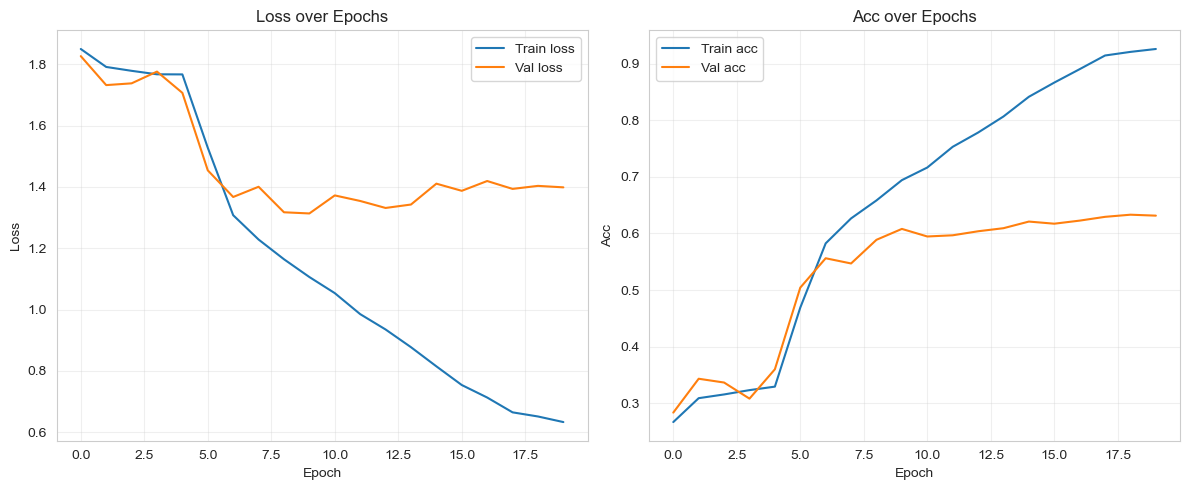

Best: 0.6332 at epoch 19


In [9]:
fig = metrics_tracker.plot_history(metrics=['loss', 'acc'], 
    save_path='../outputs/figures/training_history.png')
plt.show()

metrics_tracker.save('../outputs/logs/training_metrics.npy')

best_epoch, best_acc = metrics_tracker.get_best_epoch('val_acc', mode='max')
print(f'Best: {best_acc:.4f} at epoch {best_epoch + 1}')

## 7. Evaluate on Test Set

In [10]:
checkpoint = torch.load(Path(save_dir) / 'best_model.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])

test_metrics = trainer.validate(test_loader, epoch=0)

print('FER2013 Test Results:')
print(f"  Accuracy: {test_metrics['accuracy']:.4f}")
print(f"  F1: {test_metrics['f1_macro']:.4f}")

Epoch 0 [Val]: 100%|██████████| 449/449 [02:39<00:00,  2.81it/s, loss=1.36]


FER2013 Test Results:
  Accuracy: 0.6399
  F1: 0.6053


## 8. Cross-Dataset Evaluation


Evaluating on FER2013_Test...


Evaluating FER2013_Test: 100%|██████████| 449/449 [02:18<00:00,  3.23it/s]



FER2013_Test Results:
  Accuracy:  0.6399
  F1 (macro): 0.6053
  Precision: 0.6233
  Recall:    0.5960

Evaluating on CK+...


Evaluating CK+: 100%|██████████| 62/62 [00:53<00:00,  1.16it/s]
/Users/nyanwaiphyo/Signature Project/fer-project/notebooks/../src/utils/metrics.py:94: RuntimeWarning: invalid value encountered in divide
  cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]



CK+ Results:
  Accuracy:  0.6707
  F1 (macro): 0.5209
  Precision: 0.6064
  Recall:    0.5204

Evaluating on JAFFE...


...


FER2013_Test Results:
  Accuracy:  0.6399
  F1 (macro): 0.6053
  Precision: 0.6233
  Recall:    0.5960

Evaluating on CK+...


Evaluating CK+: 100%|██████████| 62/62 [00:42<00:00,  1.46it/s]



CK+ Results:
  Accuracy:  0.6707
  F1 (macro): 0.5209
  Precision: 0.6064
  Recall:    0.5204

Evaluating on JAFFE...


Evaluating JAFFE: 100%|██████████| 14/14 [00:28<00:00,  2.06s/it]



JAFFE Results:
  Accuracy:  0.3803
  F1 (macro): 0.3421
  Precision: 0.3448
  Recall:    0.3758

Per-Class Performance Comparison
Emotion        FER2013_Test   CK+            JAFFE          
--------------------------------------------------------------------------------
angry          0.5411         0.5491         0.0000         
disgust        0.4972         0.4271         0.0000         
fear           0.4673         0.4688         0.3429         
happy          0.8606         0.9553         0.7576         
sad            0.5156         0.3088         0.3299         
surprise       0.7582         0.9374         0.7083         
neutral        0.5971         0.0000         0.2558         


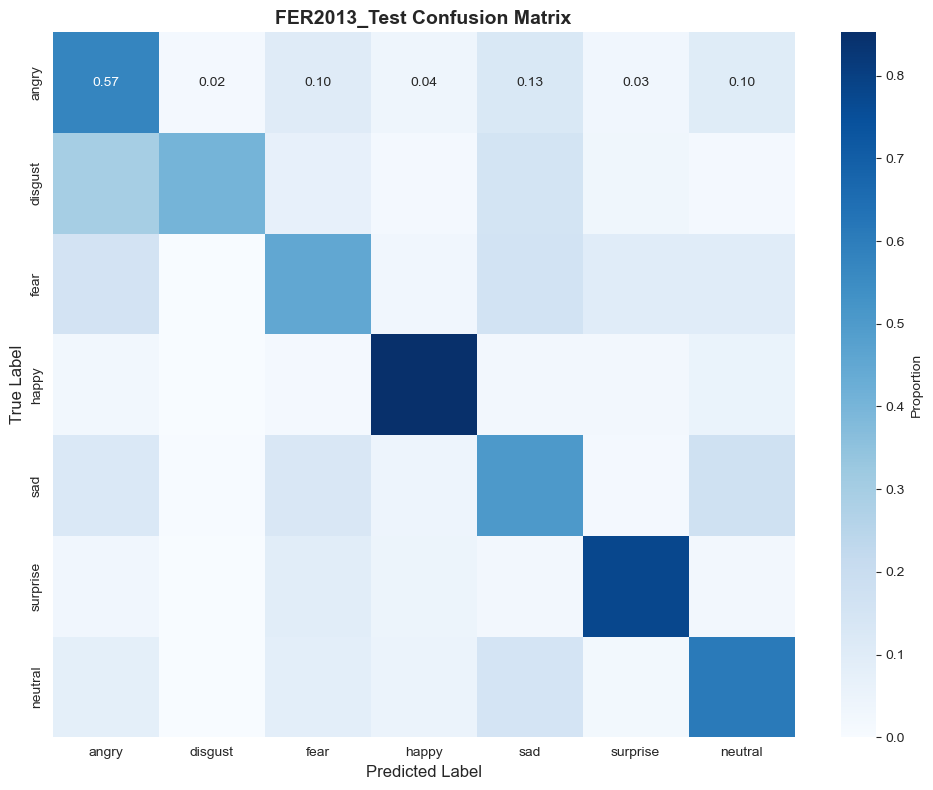

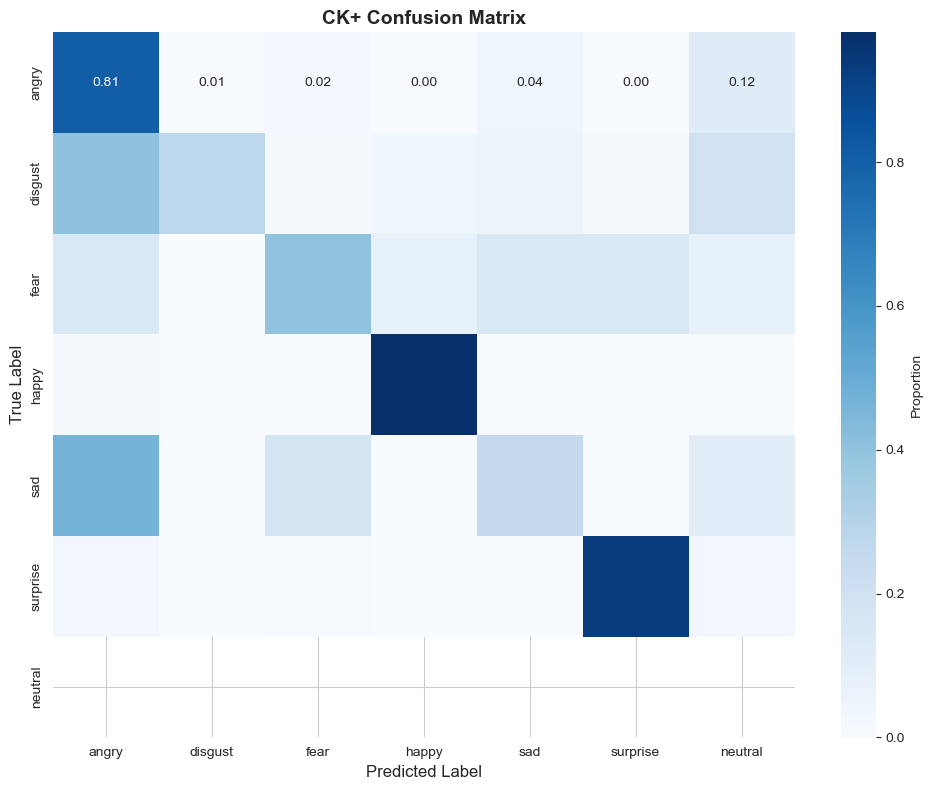

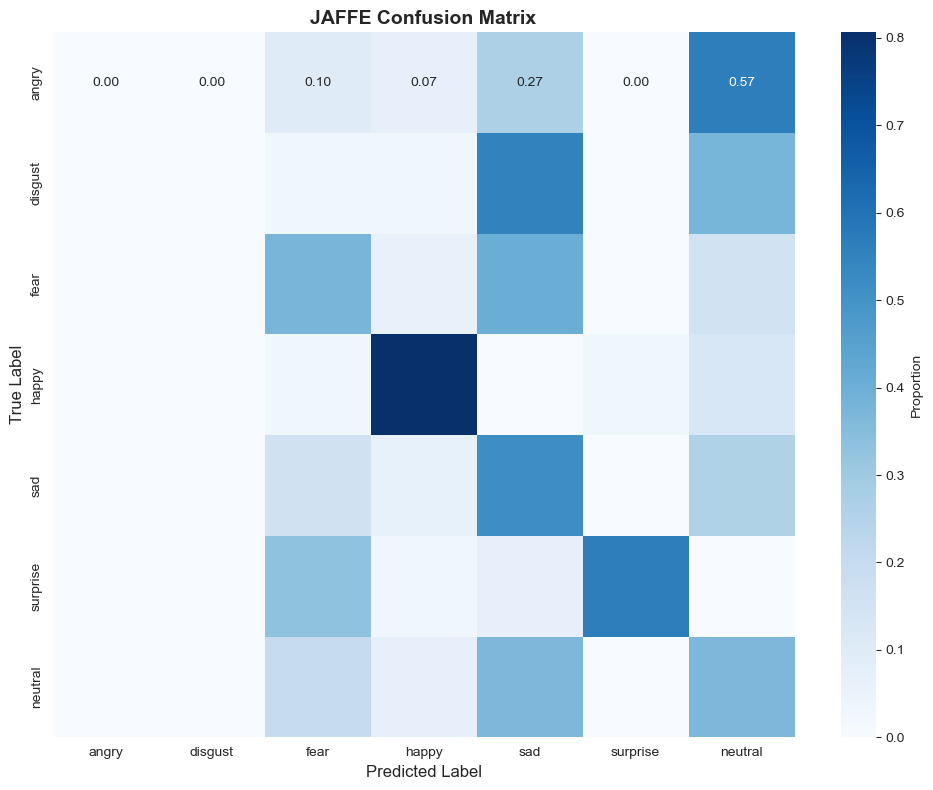

In [11]:
evaluator = CrossDatasetEvaluator(model=model, class_names=emotions, device=device)

eval_datasets = {'FER2013_Test': test_loader}
if ckplus:
    eval_datasets['CK+'] = DataLoader(ckplus, batch_size=batch_size, shuffle=False, num_workers=4)
if jaffe:
    eval_datasets['JAFFE'] = DataLoader(jaffe, batch_size=batch_size, shuffle=False, num_workers=4)

results, cms = evaluator.evaluate_all_datasets(eval_datasets, save_dir='../outputs/figures')
per_class = evaluator.compare_per_class_performance(eval_datasets)

## 9. Visualize Results

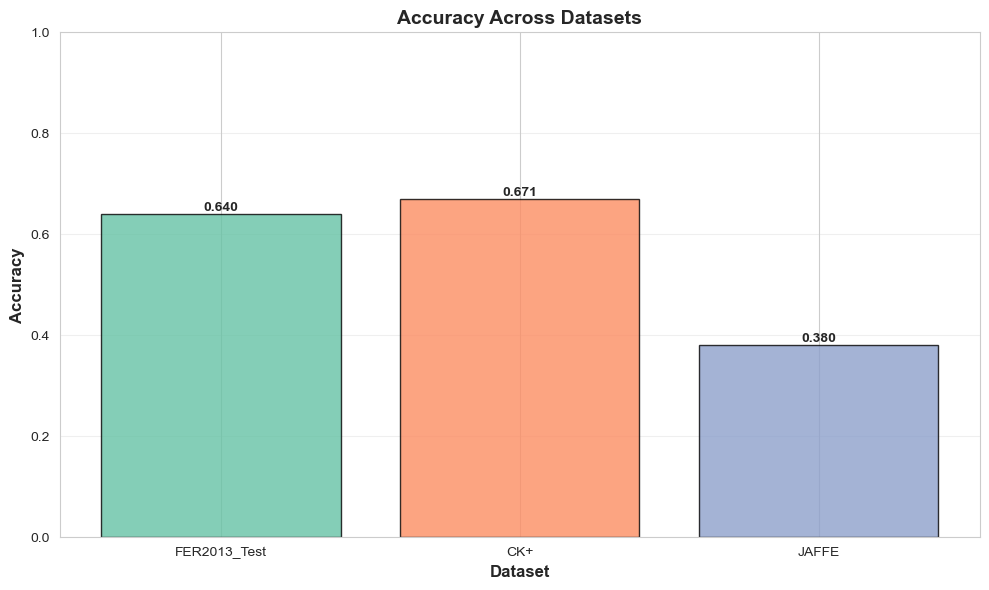

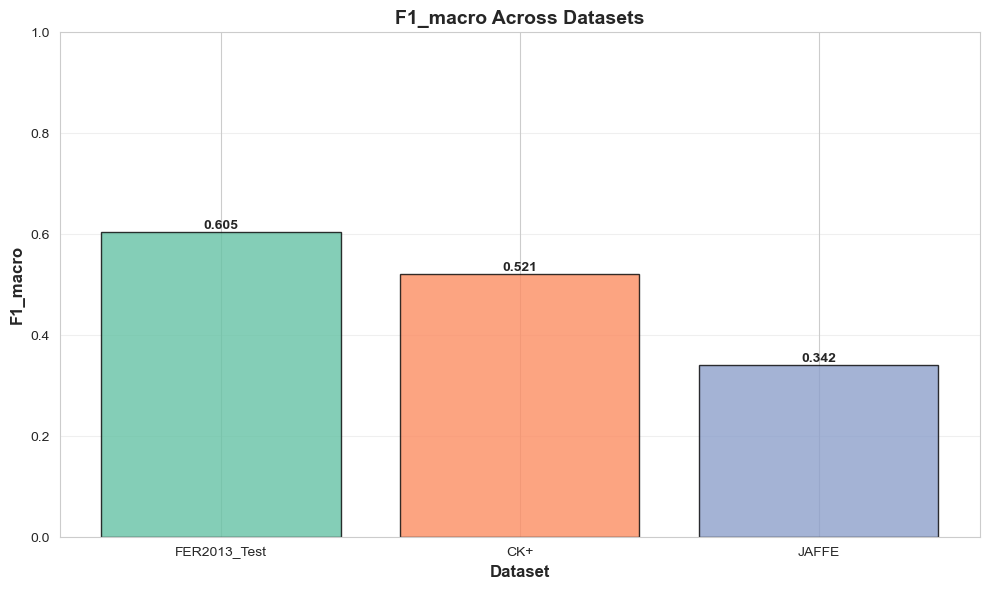


✓ Phase 3 Complete!
✓ Check outputs/ for all results


In [12]:
plot_cross_dataset_performance(results, metric='accuracy', 
    save_path='../outputs/figures/cross_dataset_accuracy.png')
plt.show()

plot_cross_dataset_performance(results, metric='f1_macro',
    save_path='../outputs/figures/cross_dataset_f1.png')
plt.show()

print('\n✓ Phase 3 Complete!')
print('✓ Check outputs/ for all results')